# Initialization

Please run all of the cells in this section before proceeding in the notebook. This will import all necessary packages and define functions used throughout the notebook.

## Imports

In [1]:
using SparseArrays, KrylovKit, LinearAlgebra, Plots, DataFrames, LsqFit, ProgressMeter, JLD, Optim, LaTeXStrings, Alert, Statistics

## Functions

In [122]:
function rot(origin, point, rot_angle)
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    The angle should be given in radians.
    """
    ox, oy = origin
    px, py = point
    
    qx = ox + cos(rot_angle) * (px - ox) - sin(rot_angle) * (py - oy)
    qy = oy + sin(rot_angle) * (px - ox) + cos(rot_angle) * (py - oy)
    
    return [Int(round(qx)), Int(round(qy))]
end;

In [123]:
function idx(i,j)
    return (i-1)*L + j
end;

function idx_inv(x)
    return Int((x/L)-mod1(x,L)/L+1), mod1(x,L)
end;

function new_idx(l,Ly)
    a,b = idx_inv(l)
    return (a-1)*Ly + b
end;

In [124]:
function hamiltonian_pbc(L,tp,t,δ,δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            push!(rows, idx(i,j))
            push!(cols, idx(i,j))
            push!(data, δ*(-1)^(i+j))            
            
            # Nearest Neighbor
            if mod(j, 2) == 0 
                push!(rows, idx(mod1(i+1,L),j)); push!(cols, idx(i,j)); push!(data, -t);
                push!(cols, idx(mod1(i+1,L),j)); push!(rows, idx(i,j)); push!(data, -t);
            else 
                push!(rows, idx(mod1(i+1,L),j)); push!(cols, idx(i,j)); push!(data, t);
                push!(cols, idx(mod1(i+1,L),j)); push!(rows, idx(i,j)); push!(data, t);
            end

            push!(rows, idx(i,mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, t);
            push!(cols, idx(i,mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, t);
            
            # Next Nearest Neighbor
            if mod(j, 2) == 1
                push!(rows, idx(mod1(i+1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                push!(cols, idx(mod1(i+1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, tp/4*im);

                push!(rows, idx(mod1(i-1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, tp/4*im);
                push!(cols, idx(mod1(i-1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, -tp/4*im);

            else
                push!(rows, idx(mod1(i+1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, tp/4*im);
                push!(cols, idx(mod1(i+1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                push!(rows, idx(mod1(i-1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                push!(cols, idx(mod1(i-1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, tp/4*im);
            end
        end
    end
    
    H = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return H
end;

In [125]:
function visualize(h,t,tp,δ,δϕ)
p1 = plot(legend=false,size=(600,600))

    for i in 1:L
        for j in 1:L
            for ip in 1:L
                for jp in 1:L
                    idx1 = idx(i,j)
                    idx2 = idx(ip,jp)
                    if round(h[idx2,idx1],digits=8) == t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:black)
                    end
                    if round(h[idx2,idx1],digits=8) == -t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:red)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                    end

                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*2*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line+[0.3,0.3], y_line, linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(H[idx2,idx1] == t*exp(im*3*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*4*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.75,0.75], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    
                    if (tp!=0)&&(round(h[idx2,idx1],digits=8) == tp/4*im)
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:orange)
                    end
                    
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange2,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:goldenrod1)
                    end
                end
            end
        end
    end
    
    if δ != 0
        for i in 1:L
            for j in 1:L
                if h[idx(i,j),idx(i,j)] == -δ
                    scatter!([i],[j],color=:black,markersize=7,markerstrokewidth=2)
                elseif h[idx(i,j),idx(i,j)] == δ
                    scatter!([i],[j],color=:white,markersize=7,markerstrokewidth=2)
                end
            end
        end
    end
    
    scatter!([origin_A[1]],[origin_A[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
    annotate!(origin_A[1] + 0.2, origin_A[2] + 0.2, text(L"A", :black, 14))

    scatter!([origin_B[1]],[origin_B[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
    annotate!(origin_B[1] + 0.2, origin_B[2] + 0.2, text(L"B", :black, 14))
        
    plot(p1,layout=(1,1),size=(400,400),constrained_layout=true,axis=([], false))
end;

In [126]:
function hamiltonian_obc(L, tp, t, δ, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            push!(rows, idx(i,j))
            push!(cols, idx(i,j))
            push!(data, δ*(-1)^(i+j))

            # H[idx(i,j),idx(i,j)] = 0.5*δ*(-1)^(i+j)
            
            
            # Nearest Neighbor
            if mod(j, 2) == 0 
                if i+1 <= L 
                    push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, -t);
                    push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, -t);
                end
            else 
                if i+1 <= L 
                    push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, t);
                end
            end

            if j+1 <= L 
                if (j==L/2+1/2)&&(i>L/2+1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, exp(-im*δϕ)*t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, exp(im*δϕ)*t);
                else
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
            end
            
            # Next Nearest Neighbor
            if (j==L/2+1/2)&&(i>L/2+1/2)
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im*exp(-im*δϕ));
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im*exp(im*δϕ));

                    # H[idx(i+1,j+1),idx(i,j)] = -tp/4*im 
                end
                
                if (i - 1 > 0)&&(j + 1 <= L)&&(i==L/2+3/2)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end

                if (i - 1 > 0)&&(j + 1 <= L)&&(i>L/2+3/2)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im*exp(-im*δϕ));
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im*exp(im*δϕ));

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end
        
            elseif mod(j, 2) == 1
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im);

                    # H[idx(i+1,j+1),idx(i,j)] = -tp/4*im 
                end

                if (i - 1 > 0 && j + 1 <= L) 
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end
            else
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                    # H[idx(i+1,j+1),idx(i,j)] = tp/4*im 
                end

                if (i - 1 > 0 && j + 1 <= L)  
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = -tp/4*im 
                end
            end
        end
    end
    
    H = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return H
end;

In [127]:
function visualize_obc(h,t,tp,δ,δϕ)
    p1 = plot(legend=false,size=(600,600))
    
        for i in 1:L
            for j in 1:L
                for ip in 1:L
                    for jp in 1:L
                        idx1 = idx(i,j)
                        idx2 = idx(ip,jp)
                        if round(h[idx2,idx1],digits=8) == t
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:black)
                        end
                        if round(h[idx2,idx1],digits=8) == -t
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:red)
                        end
                        if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                        end
    
                        if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*2*δϕ))
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line+[0.3,0.3], y_line, linewidth=2,linecolor=:blue,arrow=true)
                        end
                        if (δϕ!=0)&&(H[idx2,idx1] == t*exp(im*3*δϕ))
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                        end
                        if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*4*δϕ))
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line+[0.75,0.75], linewidth=2,linecolor=:blue,arrow=true)
                        end
                        
                        if (tp!=0)&&(round(h[idx2,idx1],digits=8) == tp/4*im)
                            x_line = [i,ip]; y_line = [j,jp];
                            plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true)
                            plot!(x_line, y_line, linewidth=2,linecolor=:orange)
                        end
                        
                        if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                            x_line = [i,ip]
                            y_line = [j,jp]
                            plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true)
                            plot!(x_line, y_line, linewidth=2,linecolor=:blue)
                        end
                        if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                            x_line = [i,ip]; y_line = [j,jp];
                            plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange2,arrow=true)
                            plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2)
                        end
                        if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                            x_line = [i,ip]; y_line = [j,jp];
                            plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true)
                            plot!(x_line, y_line, linewidth=2,linecolor=:goldenrod1)
                        end
                    end
                end
            end
        end
        
        if δ != 0
            for i in 1:L
                for j in 1:L
                    if h[idx(i,j),idx(i,j)] == -δ
                        scatter!([i],[j],color=:black,markersize=7,markerstrokewidth=2)
                    elseif h[idx(i,j),idx(i,j)] == δ
                        scatter!([i],[j],color=:white,markersize=7,markerstrokewidth=2)
                    end
                end
            end
        end
        
        scatter!([origin[1]],[origin[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
         
        plot(p1,layout=(1,1),size=(400,400),constrained_layout=true,axis=([], false))
    end;

In [128]:
function disc_idx(i,j,k)
    return (j-1)*Int(L/2-1/2)*3 + (i-1)*3 + k + 1
end;

function disc_idx_inv(x)
    k = mod1(x-1,3)
    i = Int(mod(x-1-k,3*Int(L/2-1/2))/3) + 1
    j = Int((x-1-(i-1)*3-k)/(Int(L/2-1/2)*3))+1
    return i,j,k
end;

In [129]:
function idx_to_3d(idx)
    i, j, k = disc_idx_inv(idx)
    if idx == 1
        return 0, 0, 0 

    else
        if k==1
            x = Int(L/2+1/2-i)
            y = 0
            z = j-1
            return x, y, z
        end

        if k==2
            x = j-1
            y = Int(L/2+1/2-i)
            z = 0 
            return x, y, z
        end

        if k==3
            x = 0
            y = j-1
            z = Int(L/2+1/2-i)
            return x, y, z
        end
    end
end;

In [130]:
function rotate_3d(α,β,γ)
    Rz = [  cos(α) -sin(α) 0
            sin(α)  cos(α) 0
            0       0      1]

    Ry = [  cos(β)  0  sin(β)
            0       1  0
            -sin(β) 0  cos(β)]

    Rx = [  1  0       0
            0  cos(γ) -sin(γ)
            0  sin(γ) cos(γ)]
   return Rx*Ry*Rz 
end;

In [131]:
function idx_to_2d(idx)
    x,y,z = idx_to_3d(idx)
    pt = rotate_3d(0,-pi/4,pi/4)*[x,y,z]
    return pt[1], pt[2]
end;

In [132]:
function visualize_disc(H_disc,tp,t,δ,δϕ)
    p1 = plot(legend=false,size=(600,600))

    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                for ip in 1:Int(L/2-1/2)
                    for jp in 1:Int(L/2+1/2)
                        for kp in 1:3
                            idx1 = disc_idx(i,j,k)
                            idx2 = disc_idx(ip,jp,kp)
                            if H_disc[idx2,idx1] == t
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:black)
                            end
                            if H_disc[idx2,idx1] == -t
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:red)
                            end
                            if (δϕ!=0)&&(H_disc[idx2,idx1] == -t*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                            end
                            if (δϕ!=0)&&(H_disc[idx2,idx1] == t*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:blue,arrow=true)
                            end
                            if (tp!=0)&&(H_disc[idx2,idx1] == im*tp/4)
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                            end
                            if (δϕ!=0)&&(tp!=0)&&(H_disc[idx2,idx1] == im*tp/4*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:darkorange,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:darkorange2,arrow=true)
                            end
                            if (δϕ!=0)&&(tp!=0)&&(H_disc[idx2,idx1] == im*tp/4*exp(-im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:gold,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:gold,arrow=true)
                            end
                        end
                    end
                end
            end
        end
    end

    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                idx1 = disc_idx(i,j,k)
                idx2 = 1
                if H_disc[idx2,idx1] == t
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = 0,0
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:black)
                end
                
                if H_disc[idx2,idx1] == -t
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = 0,0
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:red)
                end
                
                if (tp!=0)&&(H_disc[idx2,idx1] == im*tp/4)
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = idx_to_2d(idx2)
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                    plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                elseif (tp!=0)&&(H_disc[idx2,idx1] == -im*tp/4)
                    x2, y2 = idx_to_2d(idx1)
                    x1, y1 = idx_to_2d(idx2)
                    x_line = [x2,x1]
                    y_line = [y2,y1]
                    plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                    plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                end
            end
        end
    end
    
    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                idx1 = disc_idx(i,j,k)
                if δ != 0
                    if H_disc[idx1,idx1] == δ
                        x, y = idx_to_2d(idx1)
                        scatter!([x],[y], color =:white, label = "", markersize = 10)
                    end
                    if H_disc[idx1,idx1] == -δ
                        x, y = idx_to_2d(idx1)
                        scatter!([x],[y], color =:black, label = "", markersize = 10)
                    end
                    if H_disc[1,1] == δ
                        scatter!([0],[0], color =:white, label = "", markersize = 10)
                    end
                    if H_disc[1,1] == -δ
                        scatter!([0],[0], color =:black, label = "", markersize = 10)
                    end
                end
            end
        end
    end
    
    plot(p1,size=(800,900),constrained_layout=true,axis=([], false))
end;

In [133]:
function disc_hamiltonian_A(L, tp, t, δ, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    ### BLOCK 1 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 1 and 2
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(-im*δϕ));
        push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(im*δϕ));
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, -im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, im*tp/4*exp(im*δϕ));

            push!(rows, disc_idx(i+1,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i+1,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, -im*tp/4*exp(im*δϕ));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(j, 2) == 0
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, -t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, -t);
                end
            else 
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
                end
            end

            if j+1 <= Int(L/2+1/2) 
                push!(rows, disc_idx(i,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                push!(cols, disc_idx(i,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, ((-1)^j)*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, ((-1)^j)*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,1)); push!(cols, disc_idx(i,j,1)); push!(data, ((-1)^j)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,1)); push!(rows, disc_idx(i,j,1)); push!(data, ((-1)^j)*im*tp/4);
                end   
            end
        end
    end
    
    ### BLOCK 2 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 2 and 3
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, t);
        push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, t);
        
        # Next-Nearest Neighbor
        if i<Int(L/2-1/2)
            push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, (-im*tp/4));
            push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, (im*tp/4));

            push!(rows, disc_idx(i+1,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, (im*tp/4));
            push!(cols, disc_idx(i+1,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, (-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(i, 2) == 0
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                push!(cols, disc_idx(i+1,j,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, ((-1)^i)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, ((-1)^i)*(im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,2)); push!(cols, disc_idx(i,j,2)); push!(data, ((-1)^i)*(im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,2)); push!(rows, disc_idx(i,j,2)); push!(data, ((-1)^i)*(-im*tp/4));
                end   
            end
        end
    end
    
    ### BLOCK 3 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 3 and 1
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i+1)*t);
        push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i+1)*t);
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, ((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, ((-1)^(i+1))*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, ((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i+1,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, ((-1)^(i+1))*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(i, 2) == 0
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                push!(cols, disc_idx(i+1,j,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,3)); push!(cols, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,3)); push!(rows, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*im*tp/4);
                end   
            end
        end
    end
    
    ## ORIGIN ###
    # Staggered On-Site Potential
    push!(rows, 1); push!(cols, 1); push!(data, δ);       

    # Nearest Neighbor
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    
    # Next-Nearest Neighbor
    push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,1)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,1)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,2)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,2)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,3)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,3)); push!(data, -im*tp/4);
    
    
    H = SparseArrays.sparse(rows, cols, data, 3*Int(L/2+1/2)*Int(L/2-1/2)+1, 3*Int(L/2+1/2)*Int(L/2-1/2)+1)

    return H
end;

In [134]:
function disc_hamiltonian_B(L,tp,  t, δ, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    ### BLOCK 1 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 1 and 2
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(-im*δϕ));
        push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(im*δϕ));
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, -im*tp/4*exp(im*δϕ));

            push!(rows, disc_idx(i+1,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, -im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i+1,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, im*tp/4*exp(im*δϕ));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, -δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(j, 2) == 1
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, -t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, -t);
                end
            else 
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
                end
            end

            if j+1 <= Int(L/2+1/2) 
                push!(rows, disc_idx(i,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                push!(cols, disc_idx(i,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, -((-1)^j)*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, -((-1)^j)*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,1)); push!(cols, disc_idx(i,j,1)); push!(data, -((-1)^j)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,1)); push!(rows, disc_idx(i,j,1)); push!(data, -((-1)^j)*im*tp/4);
                end   
            end
        end
    end
    
    ### BLOCK 2 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 2 and 3
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*t);
        push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*t);
        
        # Next-Nearest Neighbor
        if i<Int(L/2-1/2)
            push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, -(-1)^i*(im*tp/4));
            push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, -(-1)^i*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*(im*tp/4));
            push!(cols, disc_idx(i+1,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, -δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(i, 2) == 1
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                push!(cols, disc_idx(i+1,j,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -((-1)^i)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -((-1)^i)*(im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -((-1)^i)*(im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -((-1)^i)*(-im*tp/4));
                end   
            end
        end
    end
    
    ### BLOCK 3 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 3 and 1
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i)*t);
        push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i)*t);
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, -((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, -((-1)^(i+1))*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, -((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i+1,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, -((-1)^(i+1))*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Staggered On-Site Potential
            push!(rows, disc_idx(i,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, -δ*(-1)^(i+j));       
            
            # Nearest Neighbor
            if mod(i, 2) == 1
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                push!(cols, disc_idx(i+1,j,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*im*tp/4);
                end   
            end
        end
    end
    
    ## ORIGIN ###
    # Staggered On-Site Potential
    push!(rows, 1); push!(cols, 1); push!(data, -δ);       

    # Nearest Neighbor
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, -t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, -t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    
    # Next-Nearest Neighbor
    push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, -im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, -im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,1)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,1)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,2)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,2)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,3)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,3)); push!(data, im*tp/4);
    
    
    H = SparseArrays.sparse(rows, cols, data, 3*Int(L/2+1/2)*Int(L/2-1/2)+1, 3*Int(L/2+1/2)*Int(L/2-1/2)+1)

    return H
end;

In [135]:
circular_mean(θs) = mod(angle(sum(exp.(im .* θs))),2pi);

In [136]:
function interpolate_y(xs, ys, x_new)
    before_ind = 0
    after_ind = 0
    
    trial_ind = 1
    while before_ind == 0
        if xs[trial_ind] >= x_new
            before_ind = trial_ind-1
            after_ind = trial_ind
        end
        trial_ind += 1
    end
    
    x1 = xs[before_ind]; y1 = ys[before_ind];
    x2 = xs[after_ind]; y2 = ys[after_ind];
    
    return y1 + (y2 - y1) * (x_new - x1) / (x2 - x1)  
end;

In [137]:
function disloc_idx(i,j)
    return sum(row_lengths[1:j-1])+i
end;

function disloc_idx_inv(ind)
    register = row_lengths
    trial = 1
    while ind > register[trial]
        ind -= register[trial]
        trial += 1
    end
    
    return ind, abs(trial)
end;

function idx_to_2d(index)
    i, j = disloc_idx_inv(index)
    if j <= length(row_lengths)/2
        pt = [i+1.0,j]
    end
    
    if j > length(row_lengths)/2
        pt = [i,j]    
    end   
    
    return pt - [L/2+1,L/2+1/2] - [0.5,0]

end;

In [154]:
function disloc_hamiltonian(L, tp, t, δ, δϕ)
    δϕ = -δϕ; tp = -tp;
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            # Staggered On-Site Potential
            push!(rows, disloc_idx(i,j)); push!(cols, disloc_idx(i,j)); push!(data, δ*(-1)^(i+j))   
            
            ## Bottom ##
            if j<length(row_lengths)/2   
                # Nearest Neighbor
                if mod(i, 2) == 0
                    if j+1 <= length(row_lengths) 
                        push!(rows, disloc_idx(i,j+1)); push!(cols, disloc_idx(i,j)); push!(data, -t);
                        push!(cols, disloc_idx(i,j+1)); push!(rows, disloc_idx(i,j)); push!(data, -t);
                    end
                else 
                    if j+1 <= length(row_lengths) 
                        push!(rows, disloc_idx(i,j+1)); push!(cols, disloc_idx(i,j)); push!(data, t);
                        push!(cols, disloc_idx(i,j+1)); push!(rows, disloc_idx(i,j)); push!(data, t);
                    end
                end

                if i+1 <= len
                    push!(rows, disloc_idx(i+1,j)); push!(cols, disloc_idx(i,j)); push!(data, t);
                    push!(cols, disloc_idx(i+1,j)); push!(rows, disloc_idx(i,j)); push!(data, t);
                end

                # Next-Nearest Neighbor
                if (i+1 <= len)&&(j+1 <= length(row_lengths))
                    push!(rows, disloc_idx(i+1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, ((-1)^i)*im*tp/4);
                    push!(cols, disloc_idx(i+1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, ((-1)^i)*(-im*tp/4));
                end
                if (i-1 >= 1)&&(j+1 <= length(row_lengths))
                    push!(rows, disloc_idx(i-1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, (-(-1)^i)*im*tp/4);
                    push!(cols, disloc_idx(i-1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, (-(-1)^i)*(-im*tp/4));
                end
                
            
            elseif j==length(row_lengths)/2
                ## Middle ##
                # Nearest Neighbor
                if i+1 <= len
                    push!(rows, disloc_idx(i+1,j)); push!(cols, disloc_idx(i,j)); push!(data, t);
                    push!(cols, disloc_idx(i+1,j)); push!(rows, disloc_idx(i,j)); push!(data, t);
                end
                
                
                if i <= len/2
                    if i%2==0
                        if j+1 <= length(row_lengths) 
                            push!(rows, disloc_idx(i,j+1)); push!(cols, disloc_idx(i,j)); push!(data, -t);
                            push!(cols, disloc_idx(i,j+1)); push!(rows, disloc_idx(i,j)); push!(data, -t);
                        end
                    else
                        if j+1 <= length(row_lengths) 
                            push!(rows, disloc_idx(i,j+1)); push!(cols, disloc_idx(i,j)); push!(data, t);
                            push!(cols, disloc_idx(i,j+1)); push!(rows, disloc_idx(i,j)); push!(data, t);
                        end
                    end
                    
                    # Next-Nearest Neighbor
                    if (i < len/2)&&(j+1 <= length(row_lengths))
                        push!(rows, disloc_idx(i+1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, ((-1)^i)*im*tp/4);
                        push!(cols, disloc_idx(i+1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, ((-1)^i)*(-im*tp/4));
                    end
                    if (i-1 >= 1)&&(j+1 <= length(row_lengths))
                        push!(rows, disloc_idx(i-1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, ((-1)^i)*(-im*tp/4));
                        push!(cols, disloc_idx(i-1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, ((-1)^i)*im*tp/4);
                    end 
                end
                    
                if i >= len/2+1
                    if j+1 <= length(row_lengths)&&(i <= len)
                        push!(rows, disloc_idx(i+2,j+1)); push!(cols, disloc_idx(i,j)); push!(data, -(-1)^i*exp(-im*δϕ)*t);
                        push!(cols, disloc_idx(i+2,j+1)); push!(rows, disloc_idx(i,j)); push!(data, -(-1)^i*exp(im*δϕ)*t);
                    end
                    
                    # Next-Nearest Neighbor
                    if (i > len/2+1)&&(j+1 <= length(row_lengths))&&(i <= len)
                        push!(rows, disloc_idx(i+1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, -(-1)^i*im*tp/4*exp(-im*δϕ));
                        push!(cols, disloc_idx(i+1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, (-1)^i*(im*tp/4)*exp(im*δϕ));
                    end
                    
                    if (i >= len/2+1/2)&&(i <= len-1)
                        push!(rows, disloc_idx(i+3,j+1)); push!(cols, disloc_idx(i,j)); push!(data, (-1)^i*im*tp/4*exp(-im*δϕ));
                        push!(cols, disloc_idx(i+3,j+1)); push!(rows, disloc_idx(i,j)); push!(data, (-1)^i*(-im*tp/4)*exp(im*δϕ));
                    end
                end
            
            elseif j>length(row_lengths)/2
                ## Top ##
                # Nearest Neighbor
                if i+1 <= len
                    push!(rows, disloc_idx(i+1,j)); push!(cols, disloc_idx(i,j)); push!(data, t);
                    push!(cols, disloc_idx(i+1,j)); push!(rows, disloc_idx(i,j)); push!(data, t);
                end

                if j+1 <= length(row_lengths) 
                    push!(rows, disloc_idx(i,j+1)); push!(cols, disloc_idx(i,j)); push!(data, -(-1)^i*t);
                    push!(cols, disloc_idx(i,j+1)); push!(rows, disloc_idx(i,j)); push!(data, -(-1)^i*t);
                end

                # Next-Nearest Neighbor
                if (i+1 <= len)&&(j+1 <= length(row_lengths))
                    push!(rows, disloc_idx(i+1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, ((-1)^i)*im*tp/4);
                    push!(cols, disloc_idx(i+1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, ((-1)^i)*(-im*tp/4));
                end
                if (i-1 >= 1)&&(j+1 <= length(row_lengths))
                    push!(rows, disloc_idx(i-1,j+1)); push!(cols, disloc_idx(i,j)); push!(data, ((-1)^i)*(-im*tp/4));
                    push!(cols, disloc_idx(i-1,j+1)); push!(rows, disloc_idx(i,j)); push!(data, ((-1)^i)*im*tp/4);
                end   
            end
        end
    end
    
    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;

In [155]:
function visualize_disloc(H_disloc,tp,t,δ,δϕ)
    p1 = plot(legend=false,size=(600,600))

    for idx1 in 1:L_tot
        for idx2 in 1:L_tot
            if H_disloc[idx2,idx1] == t
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line, y_line, linewidth=2,linecolor=:black)
            end
            if H_disloc[idx2,idx1] == -t
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line, y_line, linewidth=2,linecolor=:red)
            end
            if (δϕ!=0)&&(H_disloc[idx2,idx1] == -t*exp(im*δϕ))
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line.-[0,0.2*(x2-x1)], y_line.-[0,0.2*(y2-y1)], linewidth=2,linecolor=:purple,arrow=true)
                plot!(x_line, y_line, linewidth=2,linecolor=:purple)
            end
            if (δϕ!=0)&&(H_disloc[idx2,idx1] == t*exp(im*δϕ))
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line.-[0,0.2*(x2-x1)], y_line.-[0,0.2*(y2-y1)], linewidth=2,linecolor=:blue,arrow=true)
                plot!(x_line, y_line, linewidth=2,linecolor=:blue)
            end
            if (tp!=0)&&(H_disloc[idx2,idx1] == im*tp/4)
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line.-[0,0.2*(x2-x1)], y_line.-[0,0.2*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                plot!(x_line, y_line, linewidth=2,linecolor=:orange)
            end
            if (tp!=0)&&(δϕ!=0)&&(H_disloc[idx2,idx1] == tp/4*im*exp(im*δϕ))
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line.-[0,0.2*(x2-x1)], y_line.-[0,0.2*(y2-y1)], linewidth=2,linecolor=:darkorange2,arrow=true)
                plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2)
            end
            if (tp!=0)&&(δϕ!=0)&&(H_disloc[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                x1, y1 = idx_to_2d(idx1)
                x2, y2 = idx_to_2d(idx2)
                x_line = [x1,x2]
                y_line = [y1,y2]
                plot!(x_line.-[0,0.2*(x2-x1)], y_line.-[0,0.2*(y2-y1)], linewidth=2,linecolor=:goldenrod1,arrow=true)
                plot!(x_line, y_line, linewidth=2,linecolor=:goldenrod1)
            end
        end
    end
    
    if δ != 0
        for idx1 in 1:L_tot
            x1, y1 = idx_to_2d(idx1)
            if H_disloc[idx1,idx1] == -δ
                scatter!([x1],[y1],color=:black,markersize=7,markerstrokewidth=1)
            elseif H_disloc[idx1,idx1] == δ
                scatter!([x1],[y1],color=:white,markersize=7,markerstrokewidth=1)
            end
        end
    end
    
    scatter!([origin[1]],[origin[2]],markershape=:xcross,color=:black,markersize=5,markerstrokewidth=4)
    
    plot(p1,layout=(1,1),size=(650,500),constrained_layout=true,axis=([], false))
end;

# Defect-Free Hamiltonian

In this section, we work with the Hamiltonian on a clean lattice, i.e. one without defects. We obtain eigenvalues of symmetry operators at different critical points and extract topological invariants in the gapped phases via the method of partial rotations discussed in e.g. arXiv:2303.16919.

## Gapless Calculations

The following set of calculations can be done when there are Dirac cones in the system. This occurs when the signed amplitude of the imaginary next-nearest neighbor hopping $t'$ is equal to $\pm \delta$. We want the only zero-energy states to be those due to the Dirac cones (as opposed to edge modes), so we place the system on a torus.

### Parameter Input

We have two primary parameters:
- n: determines size of lattice
- tp: strength of next-nearest neighbor coupling

In [133]:
## Model Parameters ##
n = 5;
tp = -1; # -1 or 1
viz_enabled = false;

In [108]:
## Defining Variables ##
L = 4*n;
t = 1;
δ = 1;
mu = 0.01;

rot_angle = pi/2
origin_A = [L/2+1,L/2-1];
origin_B = [L/2+1,L/2];

We construct the first quantized Hamiltonian $h$, defined so that
$$H=\sum_{i,j}c^\dagger_i h_{ij} c_j,$$
on a lattice with periodic boundary conditions.

In [109]:
h = hamiltonian_pbc(L, tp, t, δ, 0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [110]:
ishermitian(h)

true

Optionally, we can visualize the Hamiltonian (not recommended above $n\approx 8$, will take a long time):

In [111]:
if viz_enabled
    visualize(h,t,tp,δ,0)
end

### Symmetries

In this section, we construct operators implementing several symmetries of $h$ and verify that they are indeed symmetries.

#### Rotation

There are inequivalent rotation symmetries $C_{4,A}$ and $C_{4,B}$, centered at the center and corner of the rotationally symmetric unit cell, respectively. These symmetries act as
$$C_{4,o} c_{\vec\imath} C_{4,o}^\dagger  = e^{i\lambda^{4,o}_{\vec\imath}}c_{R^o_{\pi/2}(\vec\imath)},$$
where $R^o_{\pi/2}(\vec\imath)$ is the coordinate obtained by rotating $\vec\imath$ by $\pi/2$ radians about the point $o$ and $e^{i\lambda^{4,o}_{\vec\imath}}$ is a site-dependent gauge transformation. We construct unitaries which implement these transformations on the first-quantized Hamiltonian:

In [112]:
rows = []; cols = []; data = Vector{Complex{Float64}}();
for i in 1:L
    for j in 1:L
        rot_point = mod1.(rot(origin_A,[i,j],rot_angle),L)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==0)&&(j%2==0)
            push!(data, im)
        else
            push!(data, -im)
        end
    end  
end

C4_A = SparseArrays.sparse(rows, cols, data, L^2, L^2);

rows = []; cols = []; data = Vector{Complex{Float64}}();
for i in 1:L
    for j in 1:L
        rot_point = mod1.(rot(origin_B,[i,j],rot_angle),L)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==1)&&(j%2==0)
            push!(data, 1)
        else
            push!(data, -1)
        end
    end  
end

C4_B = SparseArrays.sparse(rows, cols, data, L^2, L^2);

Let's verify that $C_{4,A}$ and $C_{4,B}$ are unitary:

In [113]:
C4_A_unitary = norm(C4_A*C4_A'-I)<1e-8
C4_B_unitary = norm(C4_B*C4_B'-I)<1e-8

display(latexstring("C_{4,A}\\;\\mathrm{unitary}?:\\; \\mathrm{$C4_A_unitary}"))
display(latexstring("C_{4,B}\\;\\mathrm{unitary}?:\\; \\mathrm{$C4_B_unitary}"))

L"$C_{4,A}\;\mathrm{unitary}?:\; \mathrm{true}$"

L"$C_{4,B}\;\mathrm{unitary}?:\; \mathrm{true}$"

Let's show that $h$ has the $C_{4,A}$ and $C_{4,B}$ symmetries:

In [114]:
C4_A_comm = norm(h*C4_A-C4_A*h)
C4_B_comm = norm(h*C4_B-C4_B*h)

display(latexstring("|[h,C_{4,A}]|:\\;$C4_A_comm"))
display(latexstring("|[h,C_{4,B}]|:\\;$C4_B_comm"))

L"$|[h,C_{4,A}]|:\;0.0$"

L"$|[h,C_{4,B}]|:\;0.0$"

#### Translation

We define the translation symmetries of the rotationally invariant unit cell, which are along $\vec{v}_1=(1,1)$ and $\vec{v}_2=(-1,1)$.

In [115]:
T1 = zeros(ComplexF64,(L^2,L^2))
for i in 1:L
    for j in 1:L
        ind = idx(i,j); indpx = idx(mod1(i+1,L),mod1(j+1,L));
        if i%2==0
            T1[indpx,ind] = im
        else
            T1[indpx,ind] = -im
        end
    end
end

T2 = zeros(ComplexF64,(L^2,L^2))
for i in 1:L
    for j in 1:L
        ind = idx(i,j); indpy = idx(mod1(i-1,L),mod1(j+1,L));
        if i%2==0
            T2[indpy,ind] = -im
        else
            T2[indpy,ind] = im
        end
    end
end

Let's verify that $T_{\hat x}$ and $T_{\hat y}$ are unitary:

In [116]:
T1_unitary = norm(T1*T1'-I)<1e-8
T2_unitary = norm(T2*T2'-I)<1e-8

display(latexstring("T_{\\vec{v}_1}\\;\\mathrm{unitary}?:\\; \\mathrm{$T1_unitary}"))
display(latexstring("T_{\\vec{v}_2}\\;\\mathrm{unitary}?:\\; \\mathrm{$T2_unitary}"))

L"$T_{\vec{v}_1}\;\mathrm{unitary}?:\; \mathrm{true}$"

L"$T_{\vec{v}_2}\;\mathrm{unitary}?:\; \mathrm{true}$"

We now show that $h$ is symmetric under $T_{\hat x}$ and $T_{\hat y}$ by computing that the commutators $[h,T_{\hat x/\hat y}]$ vanish:

In [117]:
T1_comm = norm(h*T1-T1*h)
T2_comm = norm(h*T2-T2*h)

display(latexstring("|[h,T_{\\vec{v}_1}]|:\\;$T1_comm"))
display(latexstring("|[h,T_{\\vec{v}_2}]|:\\;$T2_comm"))

L"$|[h,T_{\vec{v}_1}]|:\;0.0$"

L"$|[h,T_{\vec{v}_2}]|:\;0.0$"

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum.

In [118]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

  0.078140 seconds (20 allocations: 10.084 MiB)


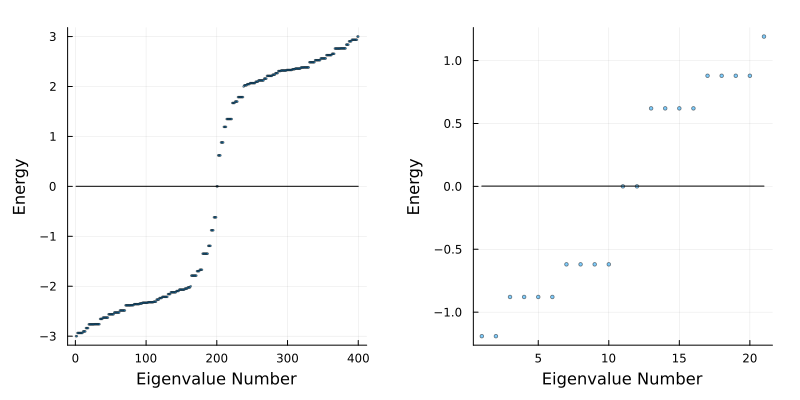

In [119]:
window = 10 # number of eigenvalues to zoom in on
mu = 0.002 # should be slightly greater than zero so all zero-energy eigenstates are included

plot1 = plot(eigenvalues,seriestype=:scatter, ms=1, ma=0.5,legend=false)
plot!(zeros(L^2) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = plot(eigenvalues[Int(round(L^2/2))-window:1:Int(round(L^2/2))+window],seriestype=:scatter, ms=2, ma=0.5,legend=false)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm)

The many-body groundstate is the Slater determinant formed from all single-particle eigenstates with energy less than the chemical potential $\mu$.

In [120]:
filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

### Symmetry Eigenvalues

In this section, we compute eigenvalues of the Dirac fermion under various spatial symmetry operations. We first have to find the degenerate zero-energy subspace.

In [121]:
zero_degen = length(findall(abs.(eigenvalues) .< 1e-5))
zero_eigs = eigenvectors[:,Int(round(L^2/2)-zero_degen/2+1):Int(round(L^2/2)+zero_degen/2)];

println("There are ",zero_degen," zero-energy eigenstates")

There are 2 zero-energy eigenstates


#### Rotations

We now construct the effective rotation operators in the zero-energy eigenspace:

In [122]:
C4_A_mat = zero_eigs'*C4_A*zero_eigs;
C4_B_mat = zero_eigs'*C4_B*zero_eigs;

Let's verify that they are still unitary matrices:

In [123]:
C4_A_zero_unitary = norm(C4_A_mat*C4_A_mat'-I)<1e-9
C4_B_zero_unitary = norm(C4_B_mat*C4_B_mat'-I)<1e-9

display(latexstring("C_{4,A}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C4_A_zero_unitary}"))
display(latexstring("C_{4,B}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C4_B_zero_unitary}"))

L"$C_{4,A}|_{E=0}\;\mathrm{unitary}?:\;\mathrm{true}$"

L"$C_{4,B}|_{E=0}\;\mathrm{unitary}?:\;\mathrm{true}$"

Diagonalizing the rotation symmetry action in the zero-energy eigenspace, we find the following eigenvalues:

In [124]:
U = eigvecs((C4_A_mat));
display(round.(diag(U'*C4_A_mat*U),digits=2))
U = eigvecs((C4_B_mat));
display(round.(diag(U'*C4_B_mat*U),digits=2))

2-element Vector{ComplexF64}:
 -0.0 - 1.0im
  1.0 + 0.0im

2-element Vector{ComplexF64}:
 -0.0 - 1.0im
  1.0 - 0.0im

We know that there exists a basis in which the Dirac fermion transforms under rotations as
$$C_{M,o}: \Psi_{\vec{k}_\star} \rightarrow e^{i\frac{2\pi}{M}s_o} \Lambda(2\pi/M)
     \Psi_{\vec{k}_\star}, $$
where $\Lambda(2\pi/M) = e^{i \frac{1}{2} \frac{2\pi}{M} \sigma^z}$. We can therefore read off the value of $s_o$ for each Dirac fermion from the eigenvalues we have calculated.

#### Translations

We now construct the effective translation operators in the zero-energy eigenspace:

In [125]:
T1_mat = zero_eigs'*T1*zero_eigs;
T2_mat = zero_eigs'*T2*zero_eigs;

We will now diagonalize the rotation symmetry action in the zero-energy eigenspace. It is crucial that we choose the same basis tranformation for both symmetries because we want to be able to pair up $k_x$ with the corresponding $k_y$. We find the following eigenvalues:

In [126]:
U = eigvecs(T1_mat);

display(round.(diag(U'*T1_mat*U),digits=2))
display(round.(diag(U'*T2_mat*U),digits=2))

2-element Vector{ComplexF64}:
 1.0 + 0.0im
 1.0 + 0.0im

2-element Vector{ComplexF64}:
 1.0 + 0.0im
 1.0 + 0.0im

We know that translations act on each Dirac fermion as
$$T_{\vec{v}}:\Psi_{k_\star}\rightarrow e^{i \vec{k}_\star\cdot \vec{v}}\Psi_{\vec{k}_\star}.$$
We can therefore read off the value of $\vec{k}_\star$ for each Dirac fermion from the eigenvalues we have calculated.

## Gapped Calculations

In this section, we will find the topological invariants in the gapped phases via partial rotations.

### Parameter Input

We have two primary parameters:
- n: determines size of lattice
- tp: strength of next-nearest neighbor coupling

In [182]:
## Model Parameters ##
n = 12;
tp = -2; # gapless at ±1

In [183]:
## Defining Variables ##
L = 4*n+1;
t = 1;
δ = 1;

rot_angle = pi/2
origin = [Int(L/2+1/2),Int(L/2+1/2)];

We construct the first quantized Hamiltonian $h$, defined so that
$$H=\sum_{i,j}c^\dagger_i h_{ij} c_j,$$
on a lattice with open boundary conditions.

In [184]:
h = hamiltonian_obc(L,tp,t,δ,0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [185]:
ishermitian(h)

true

Optionally, we can visualize the Hamiltonian:

In [186]:
viz_enabled = false # show visualization of the Hamiltonian
if viz_enabled
    visualize_obc(h,t,tp,δ,0)
end

### Symmetries

In this section, we construct operators implementing several symmetries of $h$ and verify that they are indeed symmetries.

#### Rotation

On OBC with $L$ odd, we only have a single rotation center, which is a vertex.

We construct the unitary which implements this transformations on the first-quantized Hamiltonian:

In [187]:
rows = []
cols = []
data = Vector{Complex{Float64}}()
    
for i in 1:L
    for j in 1:L
        rot_point = rot(origin,[i,j],rot_angle)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==0)&&(j%2==0)
            push!(data, im)
        else
            push!(data, -im)
        end
    end  
end

C4 = SparseArrays.sparse(rows, cols, data, L^2, L^2);

Let's verify that $C_{4}$ is unitary:

In [188]:
println("C_4 unitary?: ",norm(C4*C4'-I)<1e-8)

C_4 unitary?: true


In [189]:
println("|[h,C_4]|: ",norm(h*C4-C4*h))

|[h,C_4]|: 0.0


#### Translation

There is no exact translation symmetry for the lattice on open boundary conditions.

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum. This time, we will see a gapped bulk spectrum, possibly with an edge mode if we are tuned to a phase with nonzero $C$.

In [190]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

  3.662392 seconds (23 allocations: 353.762 MiB, 2.38% gc time)


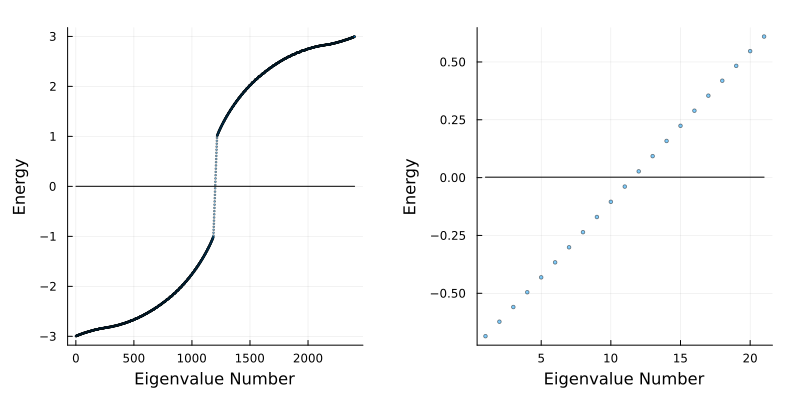

In [191]:
window = 10 # number of eigenvalues to zoom in on

plot1 = plot(eigenvalues,seriestype=:scatter, ms=1, ma=0.5,legend=false)
plot!(zeros(L^2) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = plot(eigenvalues[Int(round(L^2/2))-window:1:Int(round(L^2/2))+window],seriestype=:scatter, ms=2, ma=0.5,legend=false)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm)

The many-body groundstate is the Slater determinant formed from all single-particle eigenstates with energy less than the chemical potential $\mu$.

In [192]:
mu = 0.002 # should be slightly greater than zero so all zero-energy eigenstates are included

filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

### Partial Rotations

In this section, we will calculate topological invariants in the gapped phases via partial rotations. Throughout we will reference definitions and formulae from arXiv:2303.16919.

We will construct the two sets of operators $\tilde C_{4,\chi}^{+}$ and $\tilde C_{4,\chi}^{-}$. These are both symmetries of $h$, but one is order-four while the other is order-eight.

In [193]:
function C4_tilde_plus(L,R,χ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            if (i>=Int(L/2+1/2)-R)&&(i<=Int(L/2+1/2)+R)&&(j>=Int(L/2+1/2)-R)&&(j<=Int(L/2+1/2)+R)
                rot_point = rot(origin,[i,j],rot_angle)
                push!(rows, idx(rot_point[1],rot_point[2]))
                push!(cols, idx(i,j))
                if (i%2==0)&&(j%2==0)
                    push!(data, im*exp(im*χ*pi/2))
                else
                    push!(data, -im*exp(im*χ*pi/2))
                end
            else
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data,1);
            end
        end  
    end
    
    M = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return M
end;

function C4_tilde_minus(L,R,χ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            if (i>=Int(L/2+1/2)-R)&&(i<=Int(L/2+1/2)+R)&&(j>=Int(L/2+1/2)-R)&&(j<=Int(L/2+1/2)+R)
                rot_point = rot(origin,[i,j],rot_angle)
                push!(rows, idx(rot_point[1],rot_point[2]))
                push!(cols, idx(i,j))
                if (i%2==0)&&(j%2==0)
                    push!(data, im*exp(im*χ*pi/2)*exp(im*pi/4))
                else
                    push!(data, -im*exp(im*χ*pi/2)*exp(im*pi/4))
                end
            else
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data,1);
            end
        end  
    end
    
    M = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return M
end;

These operators should be symmetries which satisfy $(\tilde C_{4,\chi}^{+})=+I$ and $(\tilde C_{4,\chi}^{-})^4=(-1)^{F}$, which we verify:

In [194]:
M = C4_tilde_plus(L,L/2,0)
display(L"(C^+_4)^4=I?:")
println(norm(M*M*M*M - I)<1e-8)
display(L"[C^+_4,h]:")
println(norm(M*h-h*M))

M = C4_tilde_minus(L,L/2,0)
display(L"(C^-_4)^4=-I?:")
println(norm(M*M*M*M + I)<1e-8)
display(L"[C^-_4,h]:")
println(norm(M*h-h*M))

L"$(C^+_4)^4=I?:$"

true


L"$[C^+_4,h]:$"

0.0


L"$(C^-_4)^4=-I?:$"

true


L"$[C^-_4,h]:$"

0.0


We now want to restrict $C_{4,\chi}^\pm$ to a rotationally invariant set of sites $D$, which we denote $C_{4,\chi}^\pm|_D$. We want to choose the radius $R$ to be sufficiently large so that we capture the bulk behavior, without making it so large that the edge influences the result.

We can then extract universal information via the formula:
\begin{equation*}
   \bra{\Psi}C_{M,o,\chi}^{\pm}|_D\ket{\Psi}=e^{\frac{2\pi i}{M}l_{D,o,\chi}^{\pm}-\gamma_{D,o,\chi}^{\pm}},
\end{equation*}
where $\gamma_{D,o,\chi}^{\pm}\propto \partial D$ sets the real-valued amplitude and $l_{D,o,\chi}^{\pm}$ encodes the topological data. In particular, $l_{D,o,\chi}^{\pm}$ satisfies
\begin{equation}
    l_{D,o,\chi}^{\pm}= \frac{C \chi^2}{2} + \mathcal{S}_o^{\pm}\chi + K_o^{\pm}\text{ mod }M.
\end{equation}

In [195]:
χ_list = 0:3
C_tilde_plus_list = []
C_tilde_minus_list = []
l_plus_list = []
l_minus_list = []

R = 18 # partial rotation region, large but not entire system

filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

for χ in χ_list
    # Construct the rotation operator
    C_tilde_plus_chi_D = C4_tilde_plus(L,R,χ)
    C_tilde_minus_chi_D = C4_tilde_minus(L,R,χ)
    
    # Find expectation value
    expect_C_tilde_plus_chi_D = det(filled_levels' * C_tilde_plus_chi_D * filled_levels)
    expect_C_tilde_minus_chi_D = det(filled_levels' * C_tilde_minus_chi_D * filled_levels)
    
    l_plus = 2*angle(expect_C_tilde_plus_chi_D)/pi
    l_minus = 2*angle(expect_C_tilde_minus_chi_D)/pi
    
    push!(C_tilde_plus_list,expect_C_tilde_plus_chi_D)
    push!(C_tilde_minus_list,expect_C_tilde_minus_chi_D)
    push!(l_plus_list,l_plus)
    push!(l_minus_list,l_minus)
end

In [196]:
Theta_plus = mod(l_plus_list[1],2)
Theta_minus = mod(l_minus_list[1],4)
S = mod((2*(Theta_minus-Theta_plus)),4)

display(latexstring("\\Theta^+:\\;$Theta_plus"))
display(latexstring("\\Theta^-:\\;$Theta_minus"))
display(latexstring("\\mathcal{S}:\\;$S"))

L"$\Theta^+:\;1.5001289153472943$"

L"$\Theta^-:\;3.2502468182911604$"

L"$\mathcal{S}:\;3.500235805887732$"

$\Theta^+$ should be a multiple of $\frac{1}{2}$, and $\Theta^-$ should be a multiple of $\frac{1}{4}$.

#### Fitting to the $l$ vs $\chi$ curve

Let's fit a quadratic polynomial mod 4 to the $\langle \Psi|\tilde C^+_{4,\chi}|\Psi\rangle$ vs. $\chi$ data. We tune by hand $C$, $\mathcal{S}^+$, and $K^+$ to fit the data.

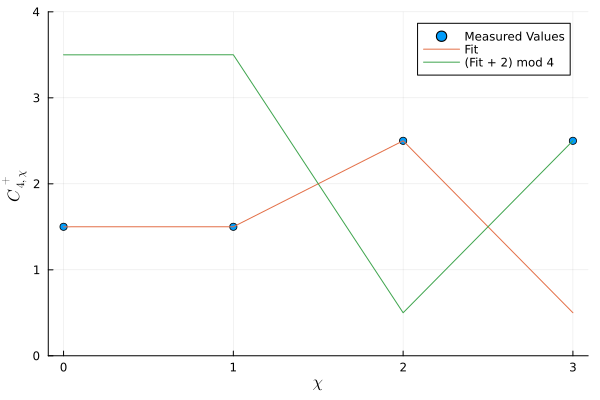

In [198]:
C = 1
S_plus = S 
K_plus = 1.5

scatter(χ_list,mod.(l_plus_list,4),ylims=(0,4),label="Measured Values")
plot!(χ_list,mod.((C/2)*(χ_list.^2) .+ S_plus*χ_list .+ K_plus,4),label="Fit")
plot!(χ_list,mod.((C/2)*(χ_list.^2) .+ S_plus*χ_list .+ K_plus .+ 2,4),label="(Fit + 2) mod 4")

xlabel!(L"\chi")
ylabel!(L"C_{4,\chi}^+")

Now, let's fit a quadratic polynomial mod 4 to the $\langle \Psi|\tilde C^-_{4,\chi}|\Psi\rangle$ vs. $\chi$ data:

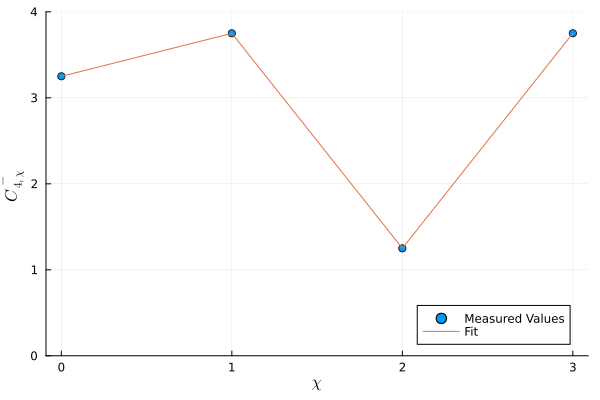

In [203]:
S_minus = 0
K_minus = 3.25

scatter(χ_list,mod.(l_minus_list,4),ylims=(0,4),label="Measured Values")
plot!(χ_list,mod.((C/2)*χ_list.^2+S_minus*χ_list.+K_minus,4),label="Fit")
xlabel!(L"\chi")
ylabel!(L"C_{4,\chi}^-")

Now that we have $K^+$ and $K^-$, we can find $\Theta^+:=K^+ \text{ mod }2$ and $\Theta^-:=K^- \text{ mod }4$ and use 
$$2(\Theta^--\Theta^+)=\mathcal{S}^+\text{ mod }4$$
to extract the discrete shift $\mathcal{S}$ and the $M=4$ relation
$$\ell=\frac{5}{4}C+2\Theta_o^+\text{ mod }4,\text{ }$$
to extract $\ell$.

In [204]:
Theta_plus = mod(K_plus,2)
Theta_minus = mod(K_minus,4)
S = mod((2*(Theta_minus-Theta_plus)),4)

l = mod((5/4)*C + 2*Theta_plus,4)

display(latexstring("C:\\;$C\\qquad \\mathcal{S}:\\;$S\\qquad \\ell:\\;$l\\qquad \\Theta^+:\\;$Theta_plus\\qquad\\Theta^-:\\;$Theta_minus"))

L"$C:\;1\qquad \mathcal{S}:\;3.5\qquad \ell:\;0.25\qquad \Theta^+:\;1.5\qquad\Theta^-:\;3.25$"

# Defect Hamiltonians

In this section, we present the code for measuring the current and energy density on a lattice with various crystalline defects.

## Disclinations

### Parameter Input

In [101]:
## PARAMETERS ##
n = 10; # tunes the size of the lattice
tp = -1; # critical points at ±1
mu = 0.002;
disc_type = "A"; # "A" or "B"
################

In [102]:
## Defining Variables ##
L = 4*n + 1
t = 1;
δ = 1;

Lx = Int(L/2-0.5)
Ly = Int(L/2+0.5);

L_tot = 3*Lx*Ly+1

rot_angle = pi/2
origin = [Int(round(L/2))+1,Int(round(L/2))+1];

In [103]:
if disc_type == "A"
    h = disc_hamiltonian_A(L,tp,t,δ,pi/4);
elseif disc_type == "B";
    h = disc_hamiltonian_B(L,tp,t,δ,pi/4);
end;

In [104]:
ishermitian(h)

true

In [105]:
viz_enabled = false;
if viz_enabled
    visualize_disc(h, tp, t, δ, pi/4)
end

### Generating Data

Here, we calculate the current and energy density in a wedge of the lattice with disclination.

In [106]:
data_list = []; H_list = [];
δϕs = 0:0.2:2*pi
@showprogress for δϕ in δϕs
    if (tp != δ)&&(tp != -δ)
        error("ERROR: Not tuned to a critical point. Ensure that tp=±δ for this calculation.")
    end
    ## Create Sparse Matrix ##
    if disc_type == "A"
        H_disc = disc_hamiltonian_A(L, tp, t, δ, δϕ-pi/2);
        # δϕ shifted to match rotation phase
        check = 0
    elseif disc_type == "B"
        H_disc = disc_hamiltonian_B(L, tp, t, δ, δϕ);
        check = 1
    end

    eigenvalues_disc, eigenvectors_disc = eigen(Matrix(H_disc));

    filled_number = count(x -> x < mu, eigenvalues_disc);
    filled_levels = eigenvectors_disc[:,1:filled_number];

    #### WEDGE 3 ####
    c_i_3 = [];c_imx_3 = [];c_imy_3 = [];c_imxmy_3 = [];c_imxpy_3 = []; 

    σi_3 = []; σj_3 = [];

    δϕ_vec_3 = [];

    x_pos_3 = []
    y_pos_3 = []

    x_distances_3 = []
    y_distances_3 = []

    cos_i_3 = []
    sin_i_3 = []

    i_3 = []
    j_3 = []
    
    global uc_indices_A = []
    global uc_indices_B = []
    global uc_indices_C = []
    global uc_indices_D = []
    

    for i in 2:Int(L/2-1/2)-1
        for j in 2:Int(L/2+1/2)-1
            ind = disc_idx(i,j,3); imx = disc_idx(i,j-1,3); imy = disc_idx(i+1,j,3);
            imxmy = disc_idx(i+1,j-1,3); imxpy = disc_idx(i+1,j+1,3);
            
            push!(uc_indices_A,ind)
            push!(uc_indices_B,imx)
            push!(uc_indices_C,imy)
            push!(uc_indices_D,disc_idx(i+1,j-1,3))
            

            push!(c_i_3,filled_levels[ind,:]); push!(c_imx_3,filled_levels[imx,:]); push!(c_imy_3,filled_levels[imy,:]); 
            push!(c_imxmy_3,filled_levels[imxmy,:]); push!(c_imxpy_3,filled_levels[imxpy,:]);

            if (i%2==check)
                push!(σi_3,-1)
            else
                push!(σi_3,1)
            end

            if (j%2==0)
                push!(σj_3,-1)
            else
                push!(σj_3,1)
            end

            if (j==Int(L/2+3/2))&&(i>Int(L/2+1/2))
                push!(δϕ_vec_3,1)
            else
                push!(δϕ_vec_3,1)
            end

            push!(x_pos_3, i)
            push!(y_pos_3, j)

            x = i-origin[1]
            y = j-origin[2]

            push!(x_distances_3,j-1)
            push!(y_distances_3,(Int(L/2-1/2)+1-i))

            push!(cos_i_3, x/sqrt(x^2+y^2))
            push!(sin_i_3, y/sqrt(x^2+y^2))

            push!(i_3,i); push!(j_3,j);
        end
    end

    c_i_3 = hcat(c_i_3...);
    c_imx_3 = hcat(c_imx_3...);
    c_imy_3 = hcat(c_imy_3...);
    c_imxmy_3 = hcat(c_imxmy_3...);
    c_imxpy_3 = hcat(c_imxpy_3...);

    #### WEDGE 3 ####
    cc_mxi_3 = transpose(sum(c_imx_3 .* conj(c_i_3),dims=1));
    cc_imx_3 = transpose(sum(c_i_3 .* conj(c_imx_3),dims=1));

    cc_myi_3 = transpose(sum(c_imy_3 .* conj(c_i_3),dims=1));
    cc_imy_3 = transpose(sum(c_i_3 .* conj(c_imy_3),dims=1));

    cc_mxmyi_3 = transpose(sum(c_imxmy_3 .* conj(c_i_3),dims=1));
    cc_imxmy_3 = transpose(sum(c_i_3 .* conj(c_imxmy_3),dims=1));

    cc_mxpyi_3 = transpose(sum(c_imxpy_3 .* conj(c_i_3),dims=1));
    cc_imxpy_3 = transpose(sum(c_i_3 .* conj(c_imxpy_3),dims=1));

    #### WEDGE 3 ####
    Jx_3 = im*t*σi_3.*(cc_imx_3.-cc_mxi_3);
    Jy_3 = im*t*(cc_imy_3.-cc_myi_3);
    Jxpy_3 = (tp/4)*σi_3.*(cc_imxmy_3.+cc_mxmyi_3);
    Jxmy_3 = -(tp/4)*σi_3.*(cc_imxpy_3.+cc_mxpyi_3);

    #### WEDGE 3 ####
    Jx_total_3 = Jx_3 #.+Jxpy_3.-Jxmy_3;
    Jy_total_3 = Jy_3 #.+Jxpy_3.+Jxmy_3;

    Jθ_micro_3 = -(y_distances_3.*(Jx_total_3))+(x_distances_3.*(Jy_total_3));
    
    global uc_indices_mat_A = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1))
    global uc_indices_mat_B = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1))
    global uc_indices_mat_C = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1))
    global uc_indices_mat_D = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1))
    data = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1))
    for i in 1:length(Jθ_micro_3)
        x = x_pos_3[i]
        y = y_pos_3[i]
        val = real.(Jθ_micro_3)[i]
        data[x,y] = val
        
        uc_indices_mat_A[x,y] = uc_indices_A[i] 
        uc_indices_mat_B[x,y] = uc_indices_B[i] 
        uc_indices_mat_C[x,y] = uc_indices_C[i] 
        uc_indices_mat_D[x,y] = uc_indices_D[i] 
    end

    data_A = data[3:2:end-1,3:2:end-1]
    data_B = data[4:2:end,3:2:end-1]
    data_C = data[4:2:end,4:2:end]
    data_D = data[3:2:end-1,4:2:end];

    global sum_data = data_A .+ data_B .+ data_C .+ data_D;
    
    global xs_run = []
    global ys_run = []
    vals = []
    for x in 1:size(sum_data)[1]
        for y in 1:size(sum_data)[2]
            val = sum_data[x,y]
            push!(xs_run,x)
            push!(ys_run,y)
            push!(vals,val)
        end
    end

    s1 = scatter(xs_run, ys_run, zcolor=vals, marker=:circle, clim=(-.02,.02), cmap=cgrad([:black,:red,:yellow,:white]), markersize=7,legend=true,size=((500,500)),markerstrokewidth=0)
    # display(s1)
    
    push!(data_list,sum_data)
    
    ## Local energy density
    local_H = diag(filled_levels*filled_levels'*H_disc);
        
    global H_i_list = []; global H_j_list = [];
    H_data = zeros((Lx,Ly))
    for i in 1:Lx
        for j in 1:Ly 
            ind = disc_idx(i,j,3)
            push!(H_i_list,i); push!(H_j_list,j);
            val = local_H[ind]
            H_data[i,j] = real(val)
        end
    end
    
    H_data_A = H_data[3:2:end-1,3:2:end-1]
    H_data_B = H_data[4:2:end,3:2:end-1]
    H_data_C = H_data[4:2:end,4:2:end]
    H_data_D = H_data[3:2:end-1,4:2:end];
    
    global local_H_sum = H_data_A .+ H_data_B .+ H_data_C .+ H_data_D;
        
    push!(H_list,local_H_sum)

    global H_xs_run = []; global H_ys_run = []; vals = [];
    global H_x_distances = []; global H_y_distances = [];
    for ind in 1:length(local_H_sum)
        i = H_i_list[ind]; j = H_j_list[ind];
        x = Lx+1-i; y = j-1;
        push!(H_xs_run,x)
        push!(H_ys_run,y)
        push!(vals,real(local_H_sum[ind]))
        push!(H_x_distances,x); push!(H_y_distances,y);
    end
    
    s2 = scatter(δϕs[1:length(data_list)],data_list)
    
#     display(s2)
        
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:19


In [107]:
data_tensor = cat(data_list...; dims=3);
H_data_tensor = cat(H_list...; dims=3);

In [108]:
x_distances_3 = []; y_distances_3 = [];
i_3 = []; j_3 = [];

for i in 2:Int(L/2-1/2)-1
    for j in 2:Int(L/2+1/2)-1
        ind = disc_idx(i,j,3); imx = disc_idx(i,j-1,3); imy = disc_idx(i+1,j,3);
        imxmy = disc_idx(i+1,j-1,3); imxpy = disc_idx(i+1,j+1,3);

        push!(x_distances_3,j-1)
        push!(y_distances_3,(Int(L/2-1/2)+1-i))
        
        push!(i_3,i); push!(j_3,j);
    end
end

x_distances_3_tensor = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1));
y_distances_3_tensor = zeros((Int(L/2-1/2)-1,Int(L/2+1/2)-1));
for i in 1:length(x_distances_3)
    x = i_3[i]
    y = j_3[i]
    x_distances_3_tensor[x,y] = x_distances_3[i];
    y_distances_3_tensor[x,y] = y_distances_3[i];
end

uc_x_distances = x_distances_3_tensor[3:2:end-1,3:2:end-1];
uc_y_distances = y_distances_3_tensor[3:2:end-1,3:2:end-1];

### Choosing sites to plot

In this section, we extract indices which are in the bulk of the lattice, neither too close to the defect core nor the edge, to include in our final plot.

In [109]:
## PARAMETERS ##
x_min_scale = -0.4; x_max_scale = -0.15; # in [-0.5,0.0]
y_min_scale = -0.4; y_max_scale = -0.15; # in [-0.5,0.0]
################

if (x_min_scale >= x_max_scale)|(y_min_scale >= y_max_scale)
    error("ERROR: Invalid bounds")
end

x_meas_indices = []; y_meas_indices = [];

for i in 1:size(uc_x_distances)[1]
    for j in 1:size(uc_x_distances)[2]
        x = uc_x_distances[i,j]; y = uc_y_distances[i,j];
        x_max = maximum(uc_x_distances); x_min = minimum(uc_x_distances); x_range = x_max - x_min;
        y_max = maximum(uc_y_distances); y_min = minimum(uc_y_distances); y_range = y_max - y_min;    

        if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
            push!(x_meas_indices,i)
            push!(y_meas_indices,j)
        end
    end
end

H_x_meas_indices = []; H_y_meas_indices = [];
for i in 1:size(uc_x_distances)[1]
    for j in 1:size(uc_x_distances)[2]
        x = uc_x_distances[i,j]; y = uc_y_distances[i,j]; 
        x_max = maximum(uc_x_distances); x_min = minimum(uc_x_distances); x_range = x_max - x_min;
        y_max = maximum(uc_y_distances); y_min = minimum(uc_y_distances); y_range = y_max - y_min; 

        if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
            push!(H_x_meas_indices,i)
            push!(H_y_meas_indices,j)
        end
    end
end


if (length(x_meas_indices)== 0)|(length(H_x_meas_indices) == 0) 
    error("ERROR: No sites in specified range. Increase system size or range cutoff.")
else 
    n_sites = length(x_meas_indices)
    println("There are $n_sites sites in the specified range")
end

There are 4 sites in the specified range


### Finding zeros and extrema

We now find the zero crossings of the current and the minima and maxima of the energy density as a function of applied flux $\delta\alpha$. 

In [110]:
x_intercept_list = []

for x_ind in x_meas_indices
    for y_ind in y_meas_indices
        xs = δϕs
        ys = data_tensor[x_ind,y_ind,:]

        old_sign = ys[end]/abs(ys[end])
        for i in 1:length(ys)
            new_sign = ys[i]/abs(ys[i])
            if old_sign < 0 && new_sign > 0
                global flip = i
            end
            old_sign = copy(new_sign)
        end

        m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
        b = ys[flip-1]

        Δx = -ys[flip-1]/m

        x_intercept = xs[flip-1]+Δx

        push!(x_intercept_list,x_intercept)
    end
end

circular_mean(x_intercept_list)

4.29303432981115

In [111]:
other_x_intercept_list = []

for x_ind in x_meas_indices
    for y_ind in y_meas_indices
        xs = δϕs
        ys = data_tensor[x_ind,y_ind,:]

        old_sign = ys[end]/abs(ys[end])
        for i in 1:length(ys)
            new_sign = ys[i]/abs(ys[i])
            if old_sign > 0 && new_sign < 0
                global flip = i
            end
            old_sign = copy(new_sign)
        end

        m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
        b = ys[flip-1]

        Δx = -ys[flip-1]/m

        x_intercept = xs[flip-1]+Δx

        push!(other_x_intercept_list,x_intercept)
    end
end

circular_mean(other_x_intercept_list)

0.7500105296343762

In [112]:
max_list = []
for i in 1:length(H_x_meas_indices)
    peak = argmax(H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:])
    xs = collect(δϕs)[peak-2:peak+2]; ys = H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],peak-2:peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(max_list,xfit[argmax(yfit)])

    # display(s)
end

circular_mean(max_list)

3.9406361831697385

In [113]:
min_list = []
for i in 1:length(H_x_meas_indices)
    peak = argmin(H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:])
    xs = collect(δϕs)[peak-2:peak+2]; ys = H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],peak-2:peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(min_list,xfit[argmin(yfit)])

    # display(s)
end

circular_mean(min_list)

0.8388386025820768

### Plotting

When we calculate the energy density, it comes with an arbitrary additive constant. In the following cell, we determine the true zero point of the energy density by finding where the energy density curves coalesce.

In [114]:
δϕs_refined = 0.1:0.0005:4
H_data_tensor_refined = zeros((length(H_x_meas_indices),length(δϕs_refined)))

for i in 1:length(H_x_meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))

y_shift = mean(H_data_tensor_refined[:,coal_ind]);

We now combine everything to create the plots seen in the manuscript.

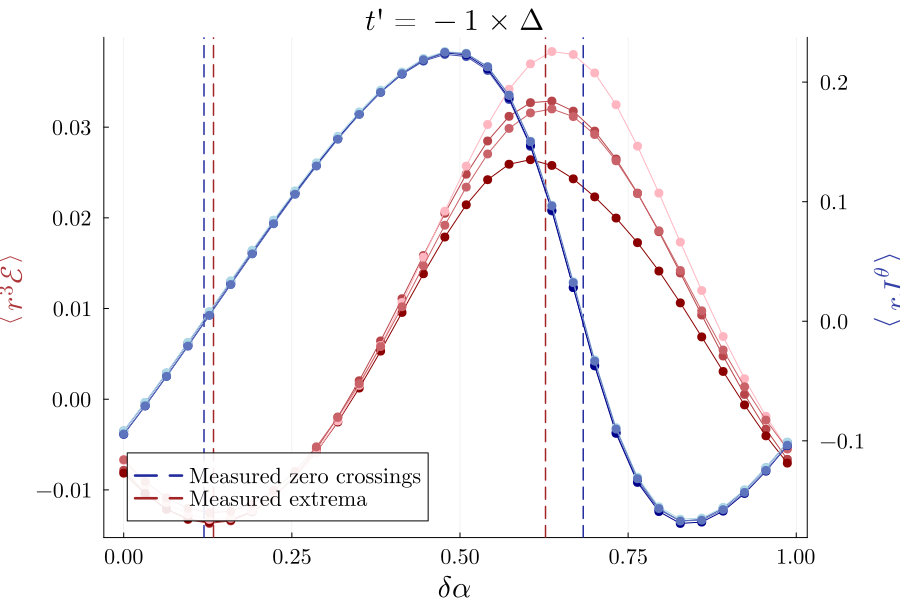

In [115]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),legend=:bottomleft,titlefont=font("Computer Modern",20), background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

distances = sqrt.((uc_x_distances[x_meas_indices,y_meas_indices].-x_origin).^2 .+ ((uc_y_distances[x_meas_indices,y_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i_iter in 1:length(x_meas_indices)
    i = x_meas_indices[i_iter]; j = y_meas_indices[i_iter];
    x_meas = uc_x_distances[i,j]; y_meas = uc_y_distances[i,j];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p,δϕs./(2*pi),(distance^power).*(H_data_tensor[i,j,:].-y_shift),label=false,color=my_color,yguidefontcolor=cgrad(:reds)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p,δϕs./(2*pi),(distance^power).*(H_data_tensor[i,j,:].-y_shift),label=false,zcolor=distance,markerstrokewidth=0,colormap=:reds, markersize=5,colorbar=false)
end

xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

p_twin = twinx(p)

distances = sqrt.((uc_x_distances[x_meas_indices,y_meas_indices].-x_origin).^2 .+ ((uc_y_distances[x_meas_indices,y_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i_iter in 1:length(x_meas_indices)
    i = x_meas_indices[i_iter]; j = y_meas_indices[i_iter];
    x_meas = uc_x_distances[i,j]; y_meas = uc_y_distances[i,j];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs./(2*pi),-(distance^power).*(data_tensor[i,j,:]),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:blues)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p_twin,δϕs./(2*pi),-(distance^power).*(data_tensor[i,j,:]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)

    rJθ = -(distance^power).*(data_tensor[i,j,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = -(distance^power).*(data_tensor[i,j,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

## Negative to Positive ##
vline!([circular_mean(x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Positive to Negative ##
vline!([circular_mean(other_x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")

title!(p,latexstring("t'=$tp\\times\\Delta"))
title!(p_twin,"")

display(p)

## Dislocation

### Parameter Input

In [194]:
## PARAMETERS ##
n = 10; # tunes the size of the lattice
tp = -1; # critical points at ±1
mu = 0.002;
################

In [195]:
## Model Parameters ##
L = 4*n;
δ = 1;
t = 1;

row_lengths = vcat([L for _ in 1:(L/2)],[L+2 for _ in 1:(L/2)])
L_tot = sum(row_lengths)
origin = [0,0];

In [196]:
h = disloc_hamiltonian(L,tp,t,δ,pi/4);

In [197]:
ishermitian(h)

true

In [198]:
viz_enabled = false;
if viz_enabled
    visualize_disloc(h, tp, t, δ, pi/4)
end

### Generating Data

Here, we calculate the current and energy density in a wedge of the lattice with disclination.

In [199]:
data_list = []; H_list = [];

δϕs = 0.0:0.2:2*pi+0.4
@showprogress for δϕ in δϕs
    ## Create Sparse Matrix ##
    H_disloc = sp_disloc_hamiltonian_pent(L, δ, tp, t, δϕ+pi); 
    # δϕ shifted to match translation phase

    eigenvalues_disloc, eigenvectors_disloc = eigen(Matrix(H_disloc));

    filled_number = count(x -> x < mu, eigenvalues_disloc);
    filled_levels = eigenvectors_disloc[:,1:filled_number];

    c_i = [];c_imx = [];c_imy = [];c_imxmy = [];c_ipxmy = []; 

    σ = [];

    δϕ_vec = [];

    global x_pos = []
    global y_pos = []

    global x_distances = []
    global y_distances = []

    cos_i = []
    sin_i = []
    
    global uc_indices_A = []; global uc_indices_B = []; global uc_indices_C = []; global uc_indices_D = [];
    
    hx = []; hy = []; hxpy = []; hymx = [];
    for i in 2:L-1
        for j in Int(L/2)+2:L-1
            ind = disloc_idx(i,j)
            imx = disloc_idx(i-1,j)
            imy = disloc_idx(i,j-1)
            imxmy = disloc_idx(i-1,j-1)
            ipxmy = disloc_idx(i+1,j-1)
            
            push!(uc_indices_A,ind)
            push!(uc_indices_B,imx)
            push!(uc_indices_C,imy)
            push!(uc_indices_D,disloc_idx(i+1,j-1))

            push!(c_i,filled_levels[ind,:])
            push!(c_imx,filled_levels[imx,:])
            push!(c_imy,filled_levels[imy,:])
            push!(c_imxmy,filled_levels[imxmy,:])
            push!(c_ipxmy,filled_levels[ipxmy,:])

            if (i%2==0)
                push!(σ,-1)
            else
                push!(σ,1)
            end

            push!(x_pos, i-1)
            push!(y_pos, j-Int(L/2)-1)
            
            x, y = idx_to_2d(ind)

            push!(x_distances, x)
            push!(y_distances, y)

            push!(cos_i, x/sqrt(x^2+y^2))
            push!(sin_i, y/sqrt(x^2+y^2))

            push!(hx,H_disloc[imx,ind])
            push!(hy,H_disloc[imy,ind])
            push!(hxpy,H_disloc[imxmy,ind])
            push!(hymx,H_disloc[ipxmy,ind])
        end
    end

    c_i = hcat(c_i...);
    c_imx = hcat(c_imx...);
    c_imy = hcat(c_imy...);
    c_imxmy = hcat(c_imxmy...);
    c_ipxmy = hcat(c_ipxmy...);

    cc_mxi = transpose(sum(c_imx .* conj(c_i),dims=1));
    cc_imx = transpose(sum(c_i .* conj(c_imx),dims=1));

    cc_myi = transpose(sum(c_imy .* conj(c_i),dims=1));
    cc_imy = transpose(sum(c_i .* conj(c_imy),dims=1));

    cc_mxmyi = transpose(sum(c_imxmy .* conj(c_i),dims=1));
    cc_imxmy = transpose(sum(c_i .* conj(c_imxmy),dims=1));

    cc_pxmyi = transpose(sum(c_ipxmy .* conj(c_i),dims=1));
    cc_ipxmy = transpose(sum(c_i .* conj(c_ipxmy),dims=1));

    Jx = im*t*(cc_imx-cc_mxi);
    Jy = im*t*σ.*(cc_imy-cc_myi);
    Jxpy = (tp/4)*σ.*(cc_imxmy+cc_mxmyi);
    Jymx = -(tp/4)*σ.*(cc_ipxmy+cc_pxmyi);

    Jx_total = Jx
    Jy_total = Jy; 

    Jθ_micro = -y_distances.*(Jx_total)+x_distances.*(Jy_total);
    
    global uc_indices_mat_A = zeros(L-2,L-2-Int(L/2))
    global uc_indices_mat_B = zeros(L-2,L-2-Int(L/2))
    global uc_indices_mat_C = zeros(L-2,L-2-Int(L/2))
    global uc_indices_mat_D = zeros(L-2,L-2-Int(L/2))

    data = zeros(L-2,L-2-Int(L/2))
    for i in 1:length(Jθ_micro)
        x = x_pos[i]
        y = y_pos[i]
        val = real.(Jθ_micro)[i]
        data[x,y] = val
        
        uc_indices_mat_A[x,y] = uc_indices_A[i] 
        uc_indices_mat_B[x,y] = uc_indices_B[i] 
        uc_indices_mat_C[x,y] = uc_indices_C[i] 
        uc_indices_mat_D[x,y] = uc_indices_D[i] 
    end

    data_A = data[3:2:end-1,3:2:end-1]
    data_B = data[4:2:end,3:2:end-1]
    data_C = data[4:2:end,4:2:end]
    data_D = data[3:2:end-1,4:2:end];

    global sum_data = data_A .+ data_B .+ data_C .+ data_D;

    global xs_run = []
    global ys_run = []
    vals = []
    for x in 1:size(sum_data)[1]
        for y in 1:size(sum_data)[2]
            val = sum_data[x,y]
            push!(xs_run,x)
            push!(ys_run,y)
            push!(vals,val)
        end
    end

    s = scatter(xs_run, ys_run, zcolor=vals, marker=:circle, clim=(-.05,.05), cmap=cgrad([:black,:red,:yellow,:white]), markersize=7,legend=true,size=((500,300)),markerstrokewidth=0)
    
    # display(s)
    
    push!(data_list,sum_data)
    
    ## Local energy density
    local_H = diag(filled_levels*filled_levels'*H_disloc);
        
    global H_i_list = []; global H_j_list = [];
    H_data = zeros((L+2,Int(L/2)))
    for i in 1:L+2
        for j in Int(L/2)+1:L
            ind = disloc_idx(i,j)
            push!(H_i_list,i); push!(H_j_list,j);
            val = local_H[ind]
            H_data[i,j-Int(L/2)] = real(val)
        end
    end
    
    H_data_A = H_data[3:2:end-1,3:2:end-1]
    H_data_B = H_data[4:2:end,3:2:end-1]
    H_data_C = H_data[4:2:end,4:2:end]
    H_data_D = H_data[3:2:end-1,4:2:end];
    
    global local_H_sum = H_data_A .+ H_data_B .+ H_data_C .+ H_data_D;
        
    push!(H_list,local_H_sum)

    global H_xs_run = []; global H_ys_run = []; vals = [];
    global H_x_distances = []; global H_y_distances = [];
    for ind in 1:length(local_H_sum)
        x = H_i_list[ind]; y = H_j_list[ind];
        # push!(xs,x)
        # push!(ys,y)
        push!(vals,real(local_H_sum[ind]))
        push!(H_x_distances,x); push!(H_y_distances,y);
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:43


In [200]:
data_tensor = cat(data_list...; dims=3);
H_data_tensor = cat(H_list...; dims=3);

In [201]:
x_distances_tensor = zeros((L-2,Int(L/2)-2));
y_distances_tensor = zeros((L-2,Int(L/2)-2));
for i in 1:length(x_distances)
    x = x_pos[i]
    y = y_pos[i]
    x_distances_tensor[x,y] = x_distances[i];
    y_distances_tensor[x,y] = y_distances[i];
end

uc_x_distances = x_distances_tensor[3:2:end-1,3:2:end-1];
uc_y_distances = y_distances_tensor[3:2:end-1,3:2:end-1];

### Choosing sites to plot

In this section, we extract indices which are in the bulk of the lattice, neither too close to the defect core nor the edge, to include in our final plot.

In [202]:
## PARAMETERS ##
x_min_scale = 0.1; x_max_scale = 0.2; # in [0.0,0.5]
y_min_scale = -0.6; y_max_scale = -0.35; # in [-1.0,0.0]
################

if (x_min_scale >= x_max_scale)|(y_min_scale >= y_max_scale)
    error("ERROR: Invalid bounds")
end

uc_meas_indices = [];
x_meas_indices = []; y_meas_indices = [];

for x in 1:size(sum_data)[1]
    for y in 1:size(sum_data)[2]
        x_max = maximum(xs_run); x_min = minimum(xs_run); x_range = x_max - x_min;
        y_max = maximum(ys_run); y_min = minimum(ys_run); y_range = y_max - y_min;    

        if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
            push!(x_meas_indices,x)
            push!(y_meas_indices,y)
        end
    end
end

if (length(x_meas_indices)== 0)|(length(H_x_meas_indices) == 0) 
    error("ERROR: No sites in specified range. Increase system size or range cutoff.")
else 
    n_sites = length(x_meas_indices)
    println("There are $n_sites sites in the specified range")
end

There are 2 sites in the specified range


### Finding zeros and extrema

We now find the zero crossings of the current and the minima and maxima of the energy density as a function of applied flux $\delta\alpha$. 

In [203]:
x_intercept_list = []

for x_ind in x_meas_indices
    for y_ind in y_meas_indices
        xs = δϕs
        ys = data_tensor[x_ind,y_ind,:]

        old_sign = ys[end]/abs(ys[end])
        for i in 1:length(ys)
            new_sign = ys[i]/abs(ys[i])
            if old_sign < 0 && new_sign > 0
                global flip = i
            end
            old_sign = copy(new_sign)
        end

        m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
        b = ys[flip-1]

        Δx = -ys[flip-1]/m

        x_intercept = xs[flip-1]+Δx

        push!(x_intercept_list,x_intercept)
    end
end

circular_mean(x_intercept_list)

3.1778010161856787

In [204]:
other_x_intercept_list = []

for x_ind in x_meas_indices
    for y_ind in y_meas_indices
        xs = δϕs
        ys = data_tensor[x_ind,y_ind,:]

        old_sign = ys[end]/abs(ys[end])
        for i in 1:length(ys)
            new_sign = ys[i]/abs(ys[i])
            if old_sign > 0 && new_sign < 0
                global flip = i
            end
            old_sign = copy(new_sign)
        end

        m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
        b = ys[flip-1]

        Δx = -ys[flip-1]/m

        x_intercept = xs[flip-1]+Δx

        push!(other_x_intercept_list,x_intercept)
    end
end

circular_mean(other_x_intercept_list)

6.191400864364551

In [205]:
max_list = []
for i in 1:length(H_x_meas_indices)
    peak = argmax(H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):min(length(δϕs),peak+2)]; ys = H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],max(1,peak-2):min(length(δϕs),peak+2)];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(max_list,xfit[argmax(yfit)])

    # display(s)
end

circular_mean(max_list)

3.0296348185062905

In [206]:
min_list = []
for i in 1:length(H_x_meas_indices)
    peak = argmin(H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):min(length(δϕs),peak+2)]; ys = H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],max(1,peak-2):min(length(δϕs),peak+2)];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(min_list,xfit[argmin(yfit)])

    # display(s)
end

circular_mean(min_list)

6.198198301832029

### Plotting

When we calculate the energy density, it comes with an arbitrary additive constant. In the following cell, we determine the true zero point of the energy density by finding where the energy density curves coalesce.

In [207]:
δϕs_refined = 0.1:0.0005:4
H_data_tensor_refined = zeros((length(H_x_meas_indices),length(δϕs_refined)))

for i in 1:length(H_x_meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, H_data_tensor[H_x_meas_indices[i],H_y_meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))

y_shift = mean(H_data_tensor_refined[:,coal_ind]);

We now combine everything to create the plots seen in the manuscript.

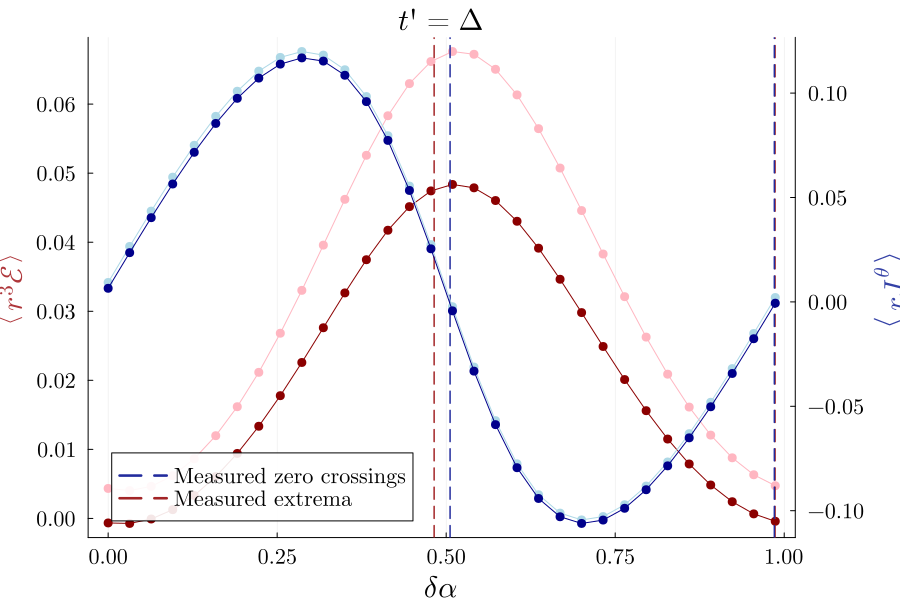

In [208]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),titlefont=font("Computer Modern", 20), legend=:bottomleft, colorbar=false, background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

distances = sqrt.((uc_x_distances[x_meas_indices,y_meas_indices].-x_origin).^2 .+ ((uc_y_distances[x_meas_indices,y_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i_iter in 1:length(x_meas_indices)
    i = x_meas_indices[i_iter]; j = y_meas_indices[i_iter];
    x_meas = uc_x_distances[i,j]; y_meas = uc_y_distances[i,j];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p,δϕs[1:end-2]./(2*pi),(distance^power).*(H_data_tensor[i,j,1:end-2].-y_shift),label=false,color=my_color,yguidefontcolor=cgrad(:reds)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p,δϕs[1:end-2]./(2*pi),(distance^power).*(H_data_tensor[i,j,1:end-2].-y_shift),label=false,zcolor=distance,markerstrokewidth=0,colormap=:reds, markersize=5,colorbar=false)
end

xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

p_twin = twinx(p)

x_origin = 0
y_origin = 0

distances = sqrt.((uc_x_distances[x_meas_indices,y_meas_indices].-x_origin).^2 .+ ((uc_y_distances[x_meas_indices,y_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i_iter in 1:length(x_meas_indices)
    i = x_meas_indices[i_iter]; j = y_meas_indices[i_iter];
    x_meas = uc_x_distances[i,j]; y_meas = uc_y_distances[i,j];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs[1:end-2]./(2*pi),-(distance^power).*(data_tensor[i,j,1:end-2]),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:blues)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p_twin,δϕs[1:end-2]./(2*pi),-(distance^power).*(data_tensor[i,j,1:end-2]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)

    rJθ = -(distance^power).*(data_tensor[i,j,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = -(distance^power).*(data_tensor[i,j,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

## Negative to Positive ##
vline!([circular_mean(x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Positive to Negative ##
vline!([circular_mean(other_x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")

title!(p,latexstring("t'=\\Delta"))
title!(p_twin,"")

display(p)